In [1]:
### imports ###
import pygmt

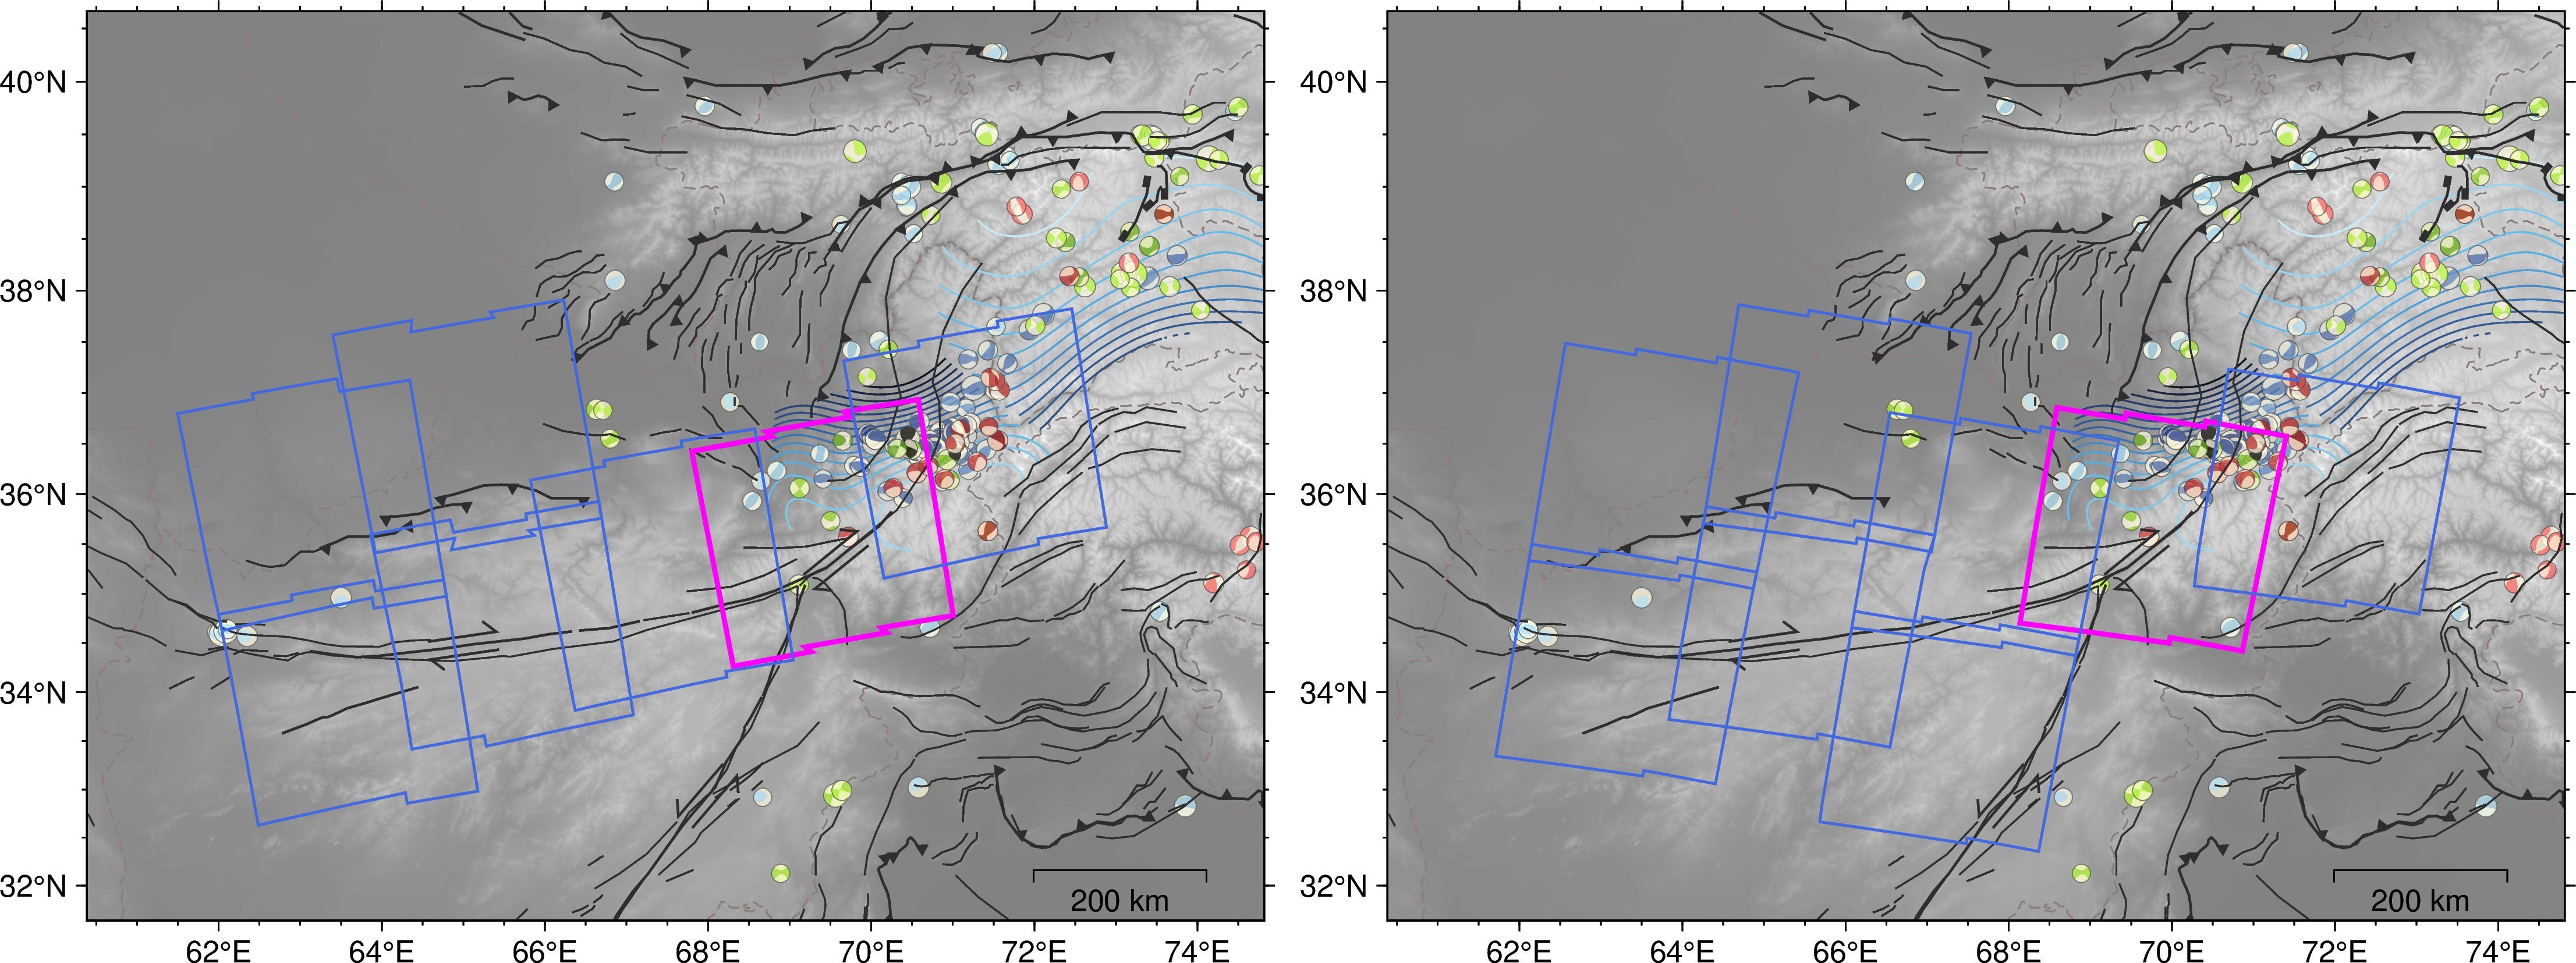

In [8]:
### GMT basemap ###
import os
dir = "/Users/rochelle/Documents/GitHub/Leeds-Research-Internship/"
os.chdir(dir)

###########################################
## Specify coords
# llcrnrlat,llcrnrlon, urcrnrlat, urcrnrlon
# are the lat/lon values of the lower left and upper right corners of the map

llcrnrlon=60.4 # lower left corner longitude 
llcrnrlat=31.65 # lower left corner latitude
urcrnrlon=74.8 # upper right corner longitude
urcrnrlat=40.65 # upper right corner latitude

proj_scale_w = 18 # specify projection scale (width)
proj_scale_unit = "c" # choose between c (cm) and i (inches)
# 17.78c = 7i

proj_subplot_scale = 2.3

meca_trans = 26 # meca transparency
meca_scale = "0.4c" # meca scale
trans = meca_trans
# InSAR_tif =
# InSAR_NetCDF =


###########################################

centerlon = (urcrnrlon - llcrnrlon)/2 + llcrnrlon # midpoints
centerlat = (urcrnrlat - llcrnrlat)/2 + llcrnrlat
region=[llcrnrlon, urcrnrlon, llcrnrlat, urcrnrlat]


fig = pygmt.Figure()
pygmt.config(MAP_FRAME_TYPE="plain", FONT="Helvetica") # figure config (borders)

with fig.subplot(
    nrows=1, ncols=2, figsize=("%s%s" % (proj_scale_w*2, proj_scale_unit)), margins="0.6c"
):
     with fig.set_panel(panel=0):
                
        fig.coast(region=region,\
          projection="M?",\
          water="white", land="grey", shorelines="1/0.5p",\
          frame=["WSne", "a2f0.5"])

          # Mercator
          # a2f0.5 --> major ticks every 2 and minor ticks every 0.5

        grid = pygmt.datasets.load_earth_relief("30s", registration="gridline", region=region)

        fig.grdimage(grid=grid, cmap="bin/cpt/custom/seabluelandgrey.cpt")
        # fig.grdimage(grid=grid, cmap="geo")

        fig.coast(map_scale="g73.05/32.1+w200k", shorelines="1/0.5p", borders="1/0.6p, mistyrose4,-")

        ## plot slab2.0 here
        fig.plot(data="bin/hin_slab2_dep_02.24.18_contours.in", pen=f"0.65p", cmap="bin/cpt/abyss_slab2.0") # Hindu Kush, bounding coords 66 74 40 34
        fig.plot(data="bin/pam_slab2_dep_02.26.18_contours.in", pen=f"0.65p", cmap="bin/cpt/abyss_slab2.0") # Pamir, bounding coords 68 78 41 35


        ## plotting HarvardCMT earthquakes by fault style 20160309 20240710
        fig.meca(
            spec="bin/Harvard_CMT_InSAR/Harvard_CMT_InSAR_thrust_dropname.xy",
            convention="mt", scale="0.28c",
            cmap="bin/cpt/custom/blue.cpt",
            extensionfill="cornsilk",
            # Draw a 0.5 points thick dark gray ("gray30") solid outline via
            # the pen parameter [Default is "0.25p,black,solid"]
            pen="thinnest,gray30,solid", transparency=trans,
        )

        fig.meca(
            spec="bin/Harvard_CMT_InSAR/Harvard_CMT_InSAR_ss_dropname.xy",
            convention="mt", scale="0.28c",
            cmap="bin/cpt/custom/green.cpt",
            extensionfill="cornsilk",
            pen="thinnest,gray30,solid", transparency=trans,
        )

        fig.meca(
            spec="bin/Harvard_CMT_InSAR/Harvard_CMT_InSAR_normal_dropname.xy",
            convention="mt", scale="0.28c",
            cmap="bin/cpt/custom/red.cpt",
            extensionfill="cornsilk",
            pen="thinnest,gray30,solid", transparency=trans,
        )

        ## plotting faults
        # https://www.pygmt.org/dev/gallery/lines/linefronts.html
        fill_fault = "grey18"
        fig.plot(data="bin/faults/HimaTibetMap.gmt", pen=f"0.65p,"+fill_fault) # all faults
        fig.plot(data="bin/faults/gem_active_faults.gmt", pen=f"0.65p,"+fill_fault) # gem active faults
        fig.plot(data="bin/faults/normal.gmt", style="f1c/0.13c+l+b", pen=f"0.95p,"+fill_fault, fill=fill_fault) # normal
        fig.plot(data="bin/faults/thrust.gmt", style="f1c/0.13c+l+t", pen=f"0.95p,"+fill_fault, fill=fill_fault) # thrust
        fig.plot(data="bin/faults/dextral.gmt", style="f5c/1c+r+s45+o2.25c", pen=f"0.95p,"+fill_fault, fill=fill_fault) # dextral (right)
        fig.plot(data="bin/faults/sinistral.gmt", style="f5c/1c+l+s45+o2.25c", pen=f"0.95p,"+fill_fault, fill=fill_fault) # sinistral (left)


        ## plotting poly.txt

        ### Ascending ###
        fig.plot(data="bin/metadata/ascending/071A_05440_131313-poly.txt", pen=f"2p,magenta") # 071A_05440_131313
        fig.plot(data="bin/metadata/ascending/173A_05350_131313-poly.txt", pen=f"1p,royalblue") # 173A_05350_131313
        fig.plot(data="bin/metadata/ascending/144A_05476_141414-poly.txt", pen=f"1p,royalblue") # 144A_05476_141414
        fig.plot(data="bin/metadata/ascending/042A_05535_131313-poly.txt", pen=f"1p,royalblue") # 042A_05535_131313
        fig.plot(data="bin/metadata/ascending/115A_05608_131313-poly.txt", pen=f"1p, royalblue")
        # fig.plot(data="bin/metadata/ascending/013A_05597_131313-poly.txt", pen=f"1p, red")
        fig.plot(data="bin/metadata/ascending/115A_05409_131313-poly.txt", pen=f"1p, royalblue")
        fig.plot(data="bin/metadata/ascending/042A_05336_131313-poly.txt", pen=f"1p, royalblue")

        '''
        ## plot initial area
        llcrnrlon=66.955 # lower left corner longitude 
        llcrnrlat=34.15 # lower left corner latitude
        urcrnrlon=72.142857 # upper right corner longitude
        urcrnrlat=37.15 # upper right corner latitude
        region_rec=[llcrnrlon, urcrnrlon, llcrnrlat, urcrnrlat]
        rectangle = [[region_rec[0], region_rec[2], region_rec[1], region_rec[3]]]

        fig.plot(data=rectangle, style="r+s", pen="1.6p,brown1")
        '''
        ###########################################################

     with fig.set_panel(panel=1):

        fig.coast(region=region,\
          projection="M?",\
          water="white", land="grey", shorelines="1/0.5p",\
          frame=["WSne", "a2f0.5"])

          # Mercator
          # a2f0.5 --> major ticks every 2 and minor ticks every 0.5

        grid = pygmt.datasets.load_earth_relief("30s", registration="gridline", region=region)

        fig.grdimage(grid=grid, cmap="bin/cpt/custom/seabluelandgrey.cpt")
        # fig.grdimage(grid=grid, cmap="geo")

        fig.coast(map_scale="g73.05/32.1+w200k", shorelines="1/0.5p", borders="1/0.6p, mistyrose4,-")
        
        ## plot slab2.0 here
        fig.plot(data="bin/hin_slab2_dep_02.24.18_contours.in", pen=f"0.65p", cmap="bin/cpt/abyss_slab2.0") # Hindu Kush, bounding coords 66 74 40 34
        fig.plot(data="bin/pam_slab2_dep_02.26.18_contours.in", pen=f"0.65p", cmap="bin/cpt/abyss_slab2.0") # Pamir, bounding coords 68 78 41 35


        ## plotting HarvardCMT earthquakes by fault style 20160309 20240710
        fig.meca(
            spec="bin/Harvard_CMT_InSAR/Harvard_CMT_InSAR_thrust_dropname.xy",
            convention="mt", scale="0.28c",
            cmap="bin/cpt/custom/blue.cpt",
            extensionfill="cornsilk",
            # Draw a 0.5 points thick dark gray ("gray30") solid outline via
            # the pen parameter [Default is "0.25p,black,solid"]
            pen="thinnest,gray30,solid", transparency=trans,
        )

        fig.meca(
            spec="bin/Harvard_CMT_InSAR/Harvard_CMT_InSAR_ss_dropname.xy",
            convention="mt", scale="0.28c",
            cmap="bin/cpt/custom/green.cpt",
            extensionfill="cornsilk",
            pen="thinnest,gray30,solid", transparency=trans,
        )

        fig.meca(
            spec="bin/Harvard_CMT_InSAR/Harvard_CMT_InSAR_normal_dropname.xy",
            convention="mt", scale="0.28c",
            cmap="bin/cpt/custom/red.cpt",
            extensionfill="cornsilk",
            pen="thinnest,gray30,solid", transparency=trans,
        )

        ## plotting faults
        # https://www.pygmt.org/dev/gallery/lines/linefronts.html
        fill_fault = "grey18"
        fig.plot(data="bin/faults/HimaTibetMap.gmt", pen=f"0.65p,"+fill_fault) # all faults
        fig.plot(data="bin/faults/gem_active_faults.gmt", pen=f"0.65p,"+fill_fault) # gem active faults
        fig.plot(data="bin/faults/normal.gmt", style="f1c/0.13c+l+b", pen=f"0.95p,"+fill_fault, fill=fill_fault) # normal
        fig.plot(data="bin/faults/thrust.gmt", style="f1c/0.13c+l+t", pen=f"0.95p,"+fill_fault, fill=fill_fault) # thrust
        fig.plot(data="bin/faults/dextral.gmt", style="f5c/1c+r+s45+o2.25c", pen=f"0.95p,"+fill_fault, fill=fill_fault) # dextral (right)
        fig.plot(data="bin/faults/sinistral.gmt", style="f5c/1c+l+s45+o2.25c", pen=f"0.95p,"+fill_fault, fill=fill_fault) # sinistral (left)


        ## plotting poly.txt

        ### Descending ###
        fig.plot(data="bin/metadata/descending/078D_05435_131313-poly.txt", pen=f"2p,magenta") # 078D_05435_131313
        fig.plot(data="bin/metadata/descending/005D_05398_131313-poly.txt", pen=f"1p,royalblue") # 005D_05398_131313
        fig.plot(data="bin/metadata/descending/151D_05440_131313-poly.txt", pen=f"1p,royalblue") # 151D_05440_131313
        fig.plot(data="bin/metadata/descending/049D_05534_131313-poly.txt", pen=f"1p,royalblue")# 049D_05534_131313
        fig.plot(data="bin/metadata/descending/122D_05571_131313-poly.txt", pen=f"1p,royalblue")
        fig.plot(data="bin/metadata/descending/049D_05335_131313-poly.txt", pen=f"1p,royalblue")
        fig.plot(data="bin/metadata/descending/122D_05372_131313-poly.txt", pen=f"1p,royalblue")
        fig.plot(data="bin/metadata/descending/151D_05639_131313-poly.txt", pen=f"1p,royalblue") # 151D_05440_131313

        '''
        ## plot initial area
        llcrnrlon=66.955 # lower left corner longitude 
        llcrnrlat=34.15 # lower left corner latitude
        urcrnrlon=72.142857 # upper right corner longitude
        urcrnrlat=37.15 # upper right corner latitude
        region_rec=[llcrnrlon, urcrnrlon, llcrnrlat, urcrnrlat]
        rectangle = [[region_rec[0], region_rec[2], region_rec[1], region_rec[3]]]

        fig.plot(data=rectangle, style="r+s", pen="1.6p,brown1")
        '''
fig.show()
fig.savefig("generating_report_figures/output_figures/final_asc_desc.png")

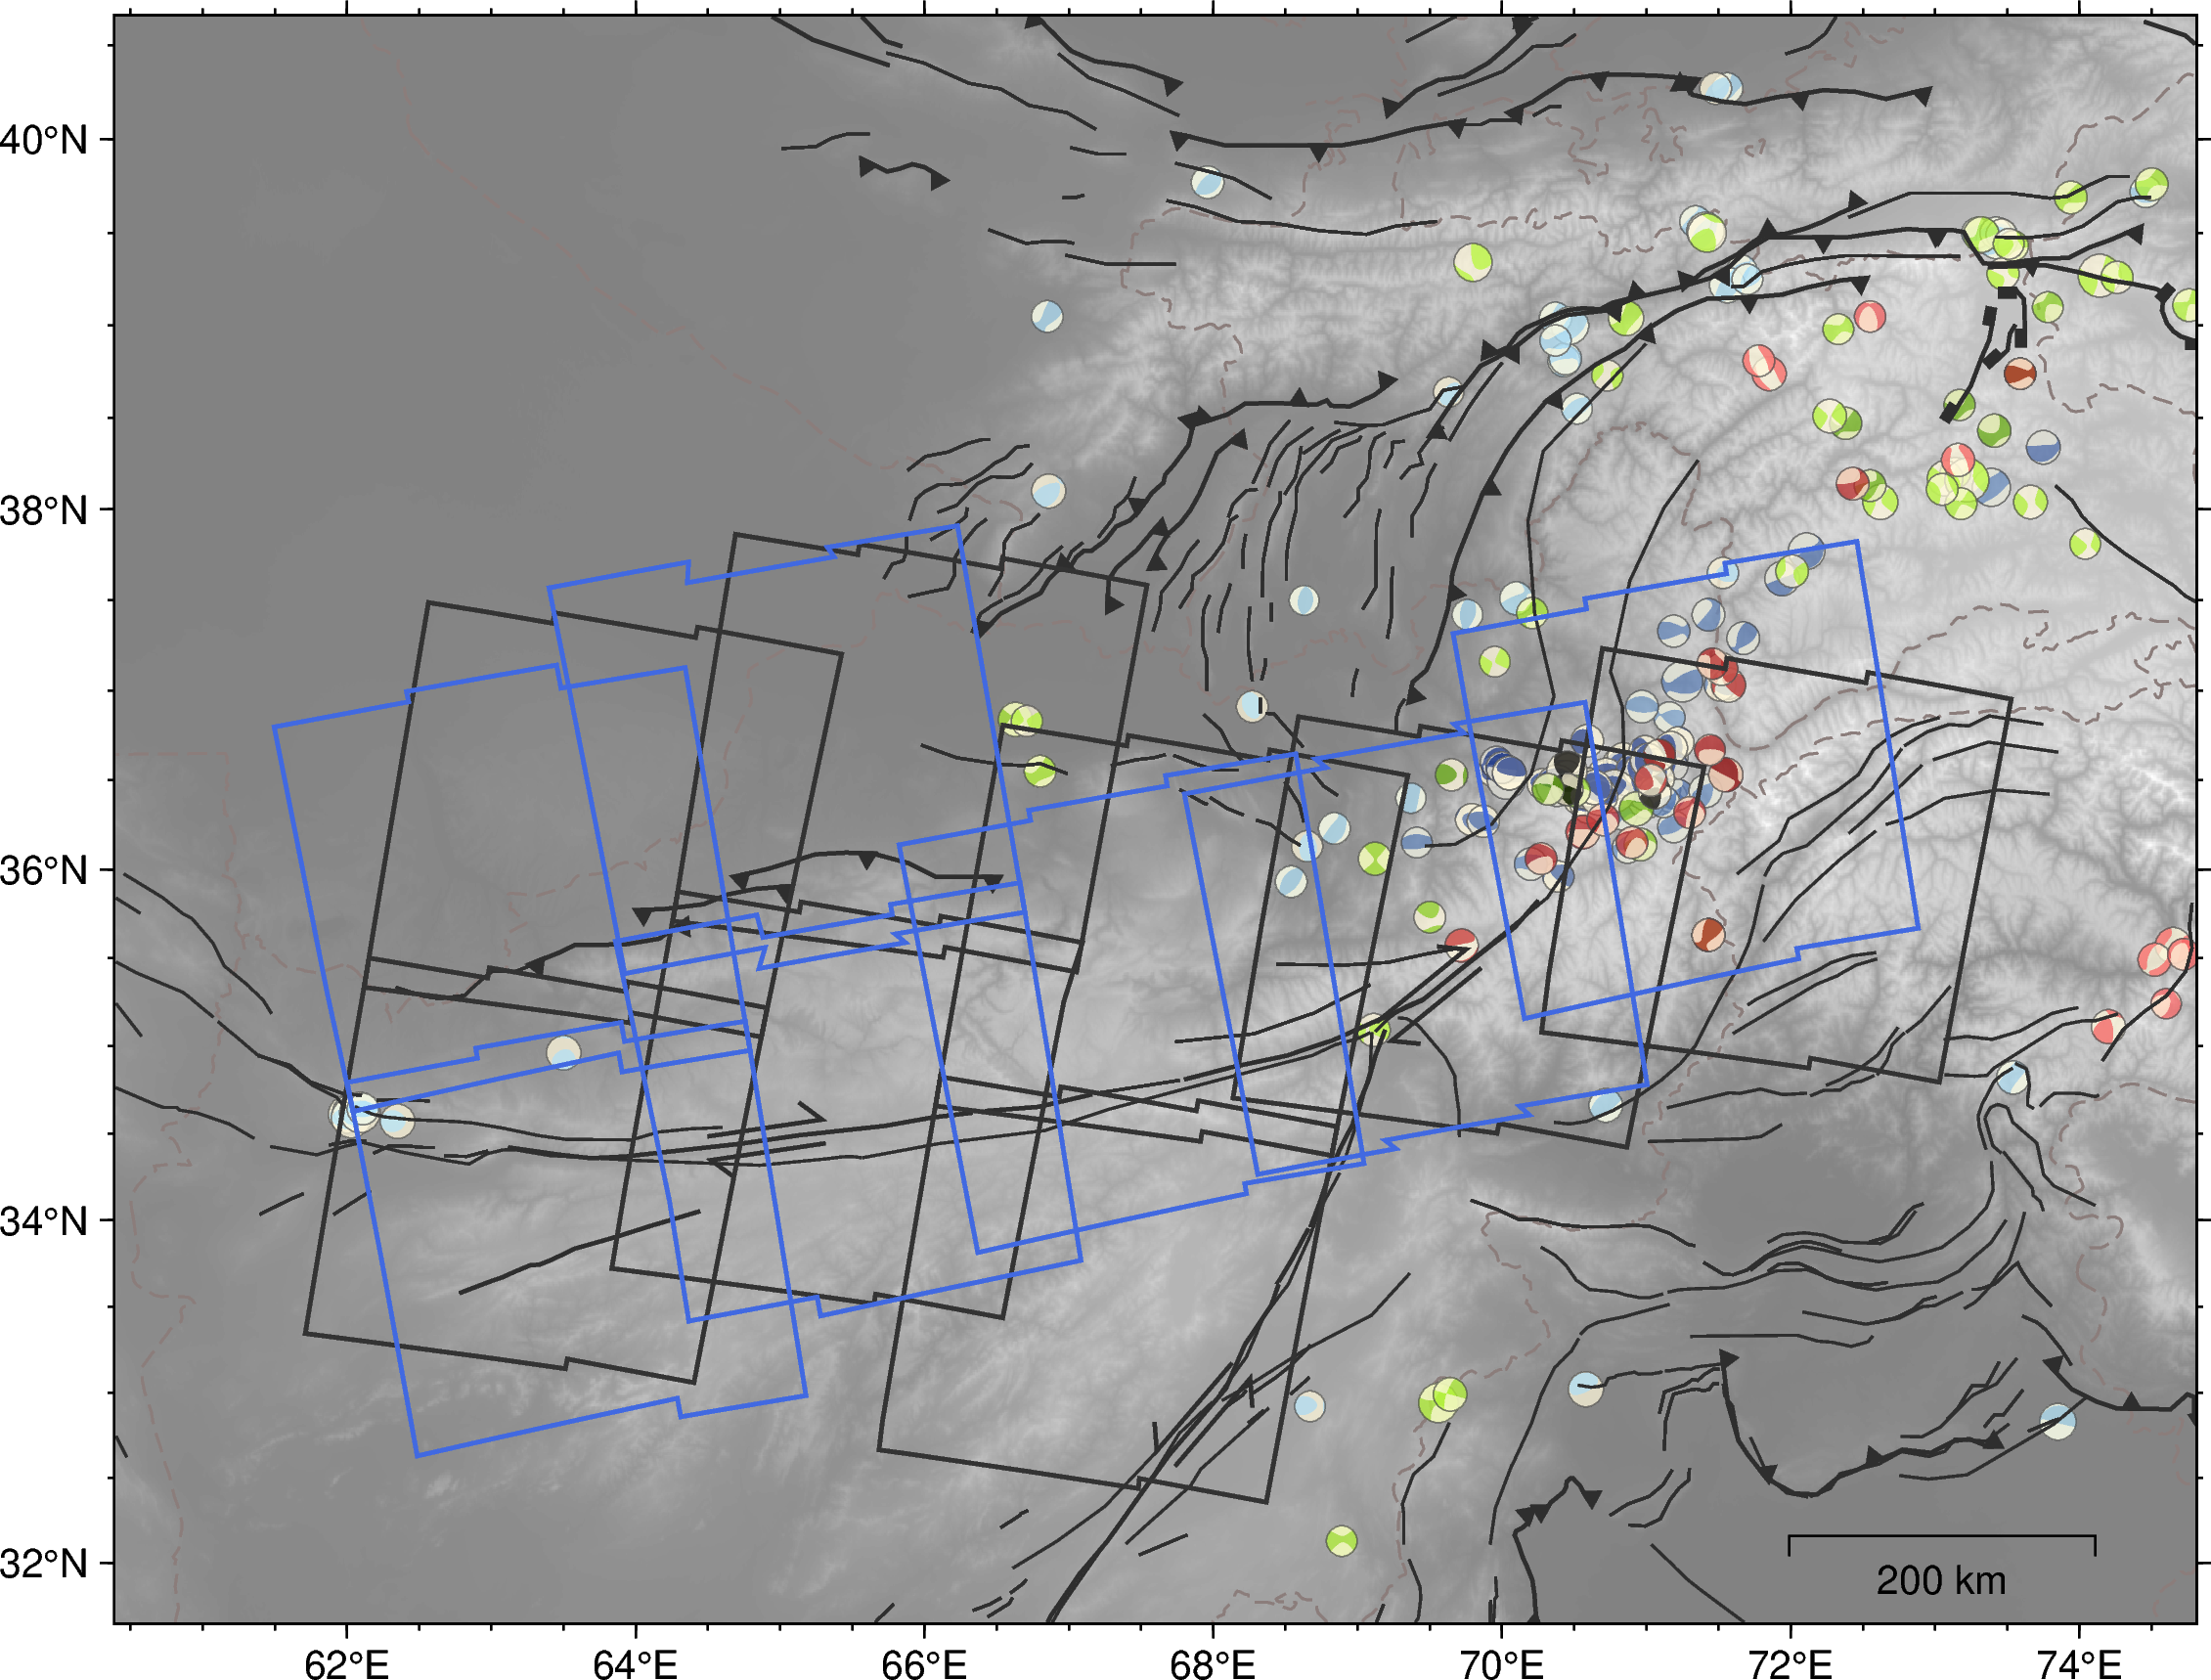

In [6]:
### GMT basemap ###
import os
dir = "/Users/rochelle/Documents/GitHub/Leeds-Research-Internship/"
os.chdir(dir)

###########################################
## Specify coords
# llcrnrlat,llcrnrlon, urcrnrlat, urcrnrlon
# are the lat/lon values of the lower left and upper right corners of the map

llcrnrlon=60.4 # lower left corner longitude 
llcrnrlat=31.65 # lower left corner latitude
urcrnrlon=74.8 # upper right corner longitude
urcrnrlat=40.65 # upper right corner latitude

proj_scale_w = 18 # specify projection scale (width)
proj_scale_unit = "c" # choose between c (cm) and i (inches)
# 17.78c = 7i

proj_subplot_scale = 2.3

meca_trans = 26 # meca transparency
meca_scale = "0.4c" # meca scale
trans = meca_trans
# InSAR_tif =
# InSAR_NetCDF =


###########################################

centerlon = (urcrnrlon - llcrnrlon)/2 + llcrnrlon # midpoints
centerlat = (urcrnrlat - llcrnrlat)/2 + llcrnrlat
region=[llcrnrlon, urcrnrlon, llcrnrlat, urcrnrlat]


fig = pygmt.Figure()
pygmt.config(MAP_FRAME_TYPE="plain", FONT="Helvetica") # figure config (borders)

fig.coast(region=region,\
    projection="M%s/%s/%s%s" % (centerlon, centerlat, proj_scale_w, proj_scale_unit),\
    water="white", land="grey", shorelines="1/0.5p",\
    frame=["WSne", "a2f0.5"])

    # Mercator
    # a2f0.5 --> major ticks every 2 and minor ticks every 0.5

grid = pygmt.datasets.load_earth_relief("30s", registration="gridline", region=region)

fig.grdimage(grid=grid, cmap="bin/cpt/custom/seabluelandgrey.cpt")
# fig.grdimage(grid=grid, cmap="geo")

fig.coast(map_scale="g73.05/32.1+w200k", shorelines="1/0.5p", borders="1/0.6p, mistyrose4,-")

## plot slab2.0 here
# fig.plot(data="bin/hin_slab2_dep_02.24.18_contours.in", pen=f"0.65p", cmap="bin/cpt/abyss_slab2.0") # Hindu Kush, bounding coords 66 74 40 34
# fig.plot(data="bin/pam_slab2_dep_02.26.18_contours.in", pen=f"0.65p", cmap="bin/cpt/abyss_slab2.0") # Pamir, bounding coords 68 78 41 35


## plotting HarvardCMT earthquakes by fault style 20160309 20240710
fig.meca(
    spec="bin/Harvard_CMT_InSAR/Harvard_CMT_InSAR_thrust_dropname.xy",
    convention="mt", scale="0.28c",
    cmap="bin/cpt/custom/blue.cpt",
    extensionfill="cornsilk",
    # Draw a 0.5 points thick dark gray ("gray30") solid outline via
    # the pen parameter [Default is "0.25p,black,solid"]
    pen="thinnest,gray30,solid", transparency=trans,
)

fig.meca(
    spec="bin/Harvard_CMT_InSAR/Harvard_CMT_InSAR_ss_dropname.xy",
    convention="mt", scale="0.28c",
    cmap="bin/cpt/custom/green.cpt",
    extensionfill="cornsilk",
    pen="thinnest,gray30,solid", transparency=trans,
)

fig.meca(
    spec="bin/Harvard_CMT_InSAR/Harvard_CMT_InSAR_normal_dropname.xy",
    convention="mt", scale="0.28c",
    cmap="bin/cpt/custom/red.cpt",
    extensionfill="cornsilk",
    pen="thinnest,gray30,solid", transparency=trans,
)

## plotting faults
# https://www.pygmt.org/dev/gallery/lines/linefronts.html
fill_fault = "grey18"
fig.plot(data="bin/faults/HimaTibetMap.gmt", pen=f"0.65p,"+fill_fault) # all faults
fig.plot(data="bin/faults/gem_active_faults.gmt", pen=f"0.65p,"+fill_fault) # gem active faults
fig.plot(data="bin/faults/normal.gmt", style="f1c/0.13c+l+b", pen=f"0.95p,"+fill_fault, fill=fill_fault) # normal
fig.plot(data="bin/faults/thrust.gmt", style="f1c/0.13c+l+t", pen=f"0.95p,"+fill_fault, fill=fill_fault) # thrust
fig.plot(data="bin/faults/dextral.gmt", style="f5c/1c+r+s45+o2.25c", pen=f"0.95p,"+fill_fault, fill=fill_fault) # dextral (right)
fig.plot(data="bin/faults/sinistral.gmt", style="f5c/1c+l+s45+o2.25c", pen=f"0.95p,"+fill_fault, fill=fill_fault) # sinistral (left)


## plotting poly.txt

### Descending ###
fig.plot(data="bin/metadata/descending/078D_05435_131313-poly.txt", pen=f"1p,grey20") # 078D_05435_131313
fig.plot(data="bin/metadata/descending/005D_05398_131313-poly.txt", pen=f"1p,grey20") # 005D_05398_131313
fig.plot(data="bin/metadata/descending/151D_05440_131313-poly.txt", pen=f"1p,grey20") # 151D_05440_131313
fig.plot(data="bin/metadata/descending/049D_05534_131313-poly.txt", pen=f"1p,grey20")# 049D_05534_131313
fig.plot(data="bin/metadata/descending/122D_05571_131313-poly.txt", pen=f"1p,grey20")
fig.plot(data="bin/metadata/descending/049D_05335_131313-poly.txt", pen=f"1p,grey20")
fig.plot(data="bin/metadata/descending/122D_05372_131313-poly.txt", pen=f"1p,grey20")
fig.plot(data="bin/metadata/descending/151D_05639_131313-poly.txt", pen=f"1p,grey20") # 151D_05440_131313

### Ascending ###
fig.plot(data="bin/metadata/ascending/071A_05440_131313-poly.txt", pen=f"1p,royalblue") # 071A_05440_131313
fig.plot(data="bin/metadata/ascending/173A_05350_131313-poly.txt", pen=f"1p,royalblue") # 173A_05350_131313
fig.plot(data="bin/metadata/ascending/144A_05476_141414-poly.txt", pen=f"1p,royalblue") # 144A_05476_141414
fig.plot(data="bin/metadata/ascending/042A_05535_131313-poly.txt", pen=f"1p,royalblue") # 042A_05535_131313
fig.plot(data="bin/metadata/ascending/115A_05608_131313-poly.txt", pen=f"1p, royalblue")
# fig.plot(data="bin/metadata/ascending/013A_05597_131313-poly.txt", pen=f"1p, red")
fig.plot(data="bin/metadata/ascending/115A_05409_131313-poly.txt", pen=f"1p, royalblue")
fig.plot(data="bin/metadata/ascending/042A_05336_131313-poly.txt", pen=f"1p, royalblue")


'''
## plot initial area
llcrnrlon=66.955 # lower left corner longitude 
llcrnrlat=34.15 # lower left corner latitude
urcrnrlon=72.142857 # upper right corner longitude
urcrnrlat=37.15 # upper right corner latitude
region_rec=[llcrnrlon, urcrnrlon, llcrnrlat, urcrnrlat]
rectangle = [[region_rec[0], region_rec[2], region_rec[1], region_rec[3]]]

fig.plot(data=rectangle, style="r+s", pen="1.6p,brown1")
'''
fig.show()
fig.savefig("generating_report_figures/output_figures/final_asc_desc_merged.png")

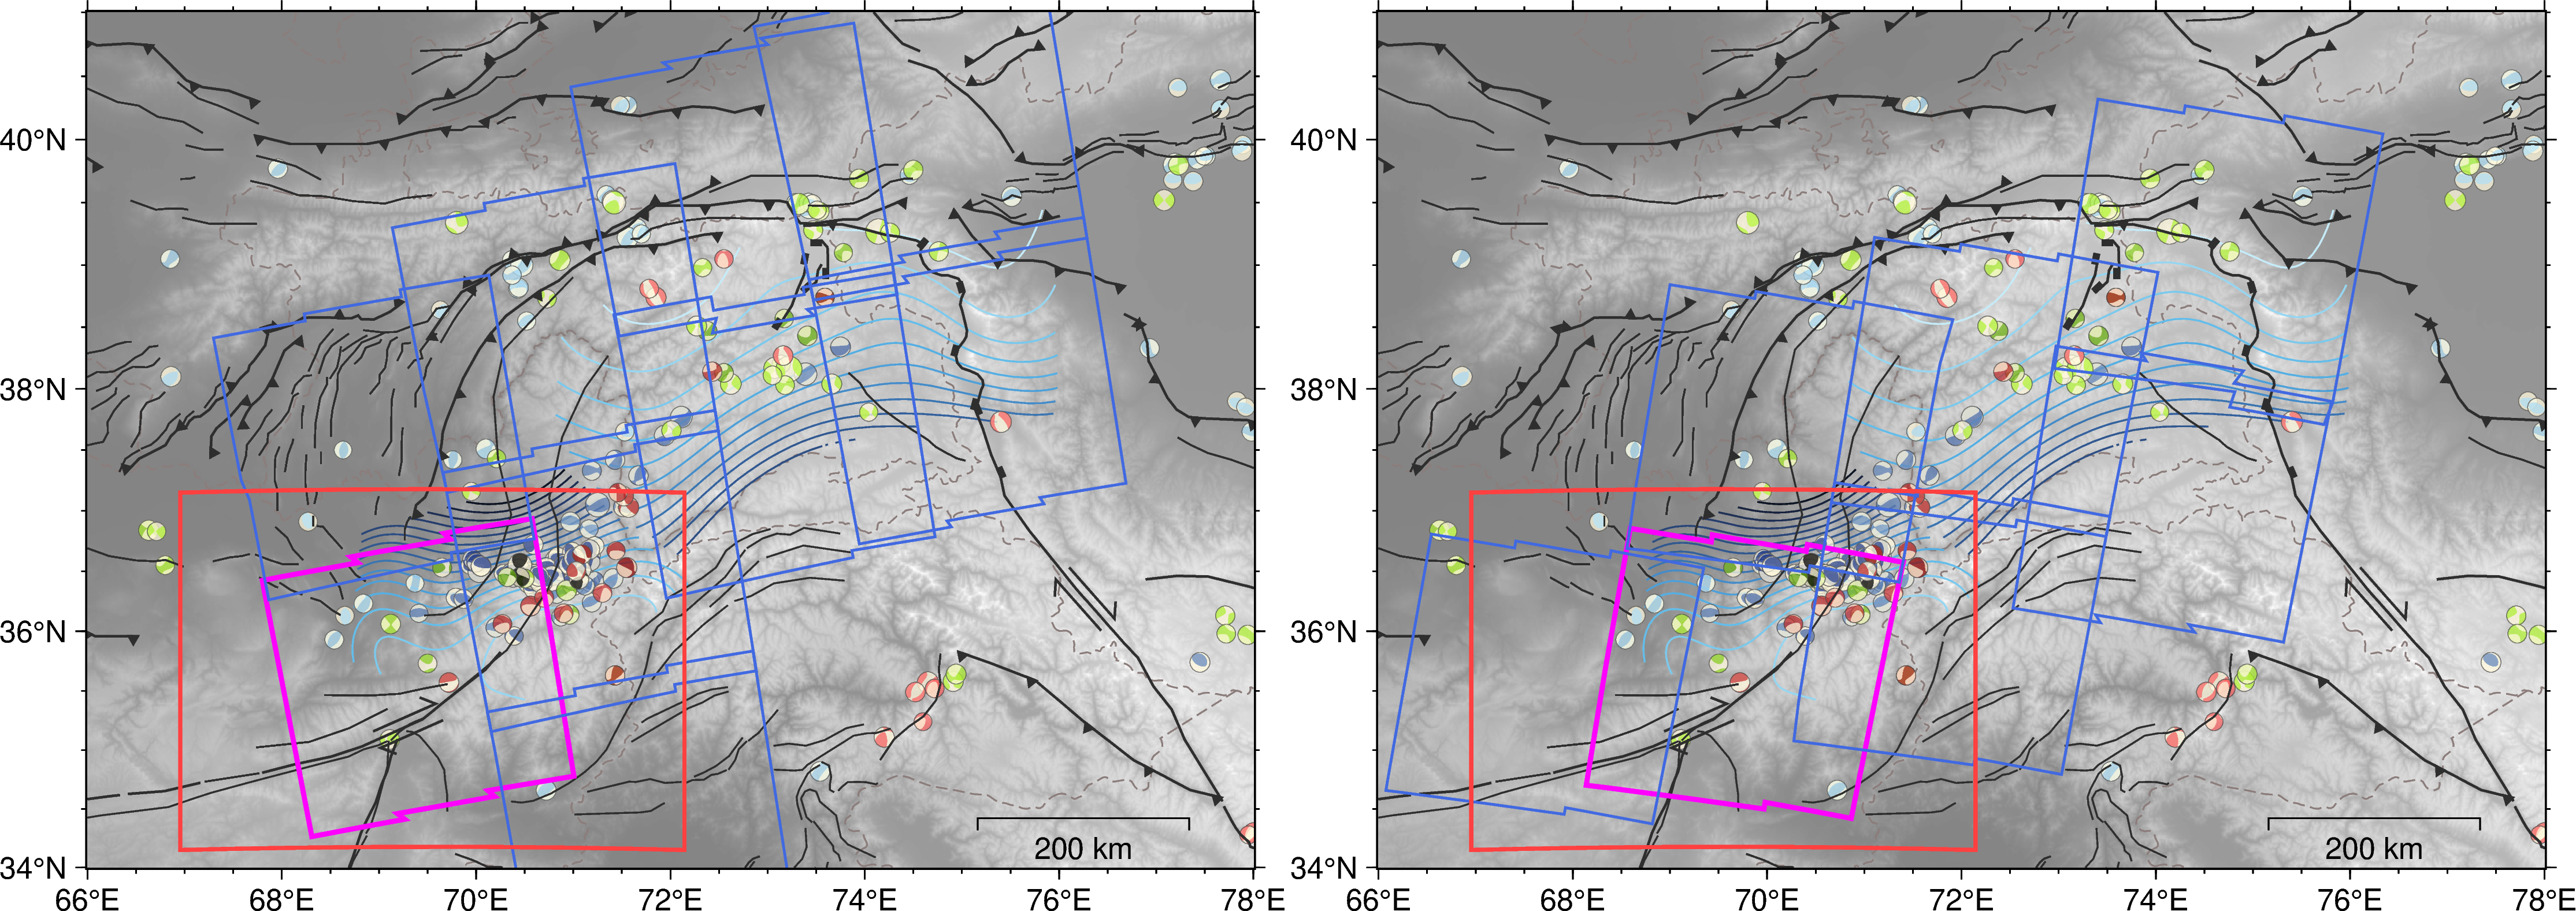

In [ ]:
### GMT basemap ###
import os
dir = "/Users/rochelle/Documents/GitHub/Leeds-Research-Internship/"
os.chdir(dir)

###########################################
## Specify coords
# llcrnrlat,llcrnrlon, urcrnrlat, urcrnrlon
# are the lat/lon values of the lower left and upper right corners of the map

llcrnrlon=66 # lower left corner longitude 
llcrnrlat=34 # lower left corner latitude
urcrnrlon=78 # upper right corner longitude
urcrnrlat=41 # upper right corner latitude


proj_scale_w = 18 # specify projection scale (width)
proj_scale_unit = "c" # choose between c (cm) and i (inches)
# 17.78c = 7i

proj_subplot_scale = 2.3

meca_trans = 26 # meca transparency
meca_scale = "0.4c" # meca scale
trans = meca_trans
# InSAR_tif =
# InSAR_NetCDF =


###########################################

centerlon = (urcrnrlon - llcrnrlon)/2 + llcrnrlon # midpoints
centerlat = (urcrnrlat - llcrnrlat)/2 + llcrnrlat
region=[llcrnrlon, urcrnrlon, llcrnrlat, urcrnrlat]


fig = pygmt.Figure()
pygmt.config(MAP_FRAME_TYPE="plain", FONT="Helvetica") # figure config (borders)

with fig.subplot(
    nrows=1, ncols=2, figsize=("%s%s" % (proj_scale_w*2, proj_scale_unit)), margins="0.6c"
):
     with fig.set_panel(panel=0):
                
        fig.coast(region=region,\
          projection="M?",\
          water="white", land="grey", shorelines="1/0.5p",\
          frame=["WSne", "a2f0.5"])

          # Mercator
          # a2f0.5 --> major ticks every 2 and minor ticks every 0.5

        grid = pygmt.datasets.load_earth_relief("30s", registration="gridline", region=region)

        fig.grdimage(grid=grid, cmap="bin/cpt/custom/seabluelandgrey.cpt")
        # fig.grdimage(grid=grid, cmap="geo")

        fig.coast(map_scale="g76.25/34.37+w200k", shorelines="1/0.5p", borders="1/0.6p, mistyrose4,-")

        ## plot slab2.0 here
        fig.plot(data="bin/hin_slab2_dep_02.24.18_contours.in", pen=f"0.65p", cmap="bin/cpt/abyss_slab2.0") # Hindu Kush, bounding coords 66 74 40 34
        fig.plot(data="bin/pam_slab2_dep_02.26.18_contours.in", pen=f"0.65p", cmap="bin/cpt/abyss_slab2.0") # Pamir, bounding coords 68 78 41 35


        ## plotting HarvardCMT earthquakes by fault style 20160309 20240710
        fig.meca(
            spec="bin/Harvard_CMT_InSAR/Harvard_CMT_InSAR_thrust_dropname.xy",
            convention="mt", scale="0.28c",
            cmap="bin/cpt/custom/blue.cpt",
            extensionfill="cornsilk",
            # Draw a 0.5 points thick dark gray ("gray30") solid outline via
            # the pen parameter [Default is "0.25p,black,solid"]
            pen="thinnest,gray30,solid", transparency=trans,
        )

        fig.meca(
            spec="bin/Harvard_CMT_InSAR/Harvard_CMT_InSAR_ss_dropname.xy",
            convention="mt", scale="0.28c",
            cmap="bin/cpt/custom/green.cpt",
            extensionfill="cornsilk",
            pen="thinnest,gray30,solid", transparency=trans,
        )

        fig.meca(
            spec="bin/Harvard_CMT_InSAR/Harvard_CMT_InSAR_normal_dropname.xy",
            convention="mt", scale="0.28c",
            cmap="bin/cpt/custom/red.cpt",
            extensionfill="cornsilk",
            pen="thinnest,gray30,solid", transparency=trans,
        )

        ## plotting faults
        # https://www.pygmt.org/dev/gallery/lines/linefronts.html
        fill_fault = "grey18"
        fig.plot(data="bin/faults/HimaTibetMap.gmt", pen=f"0.65p,"+fill_fault) # all faults
        fig.plot(data="bin/faults/gem_active_faults.gmt", pen=f"0.65p,"+fill_fault) # gem active faults
        fig.plot(data="bin/faults/normal.gmt", style="f1c/0.13c+l+b", pen=f"0.95p,"+fill_fault, fill=fill_fault) # normal
        fig.plot(data="bin/faults/thrust.gmt", style="f1c/0.13c+l+t", pen=f"0.95p,"+fill_fault, fill=fill_fault) # thrust
        fig.plot(data="bin/faults/dextral.gmt", style="f5c/1c+r+s45+o2.25c", pen=f"0.95p,"+fill_fault, fill=fill_fault) # dextral (right)
        fig.plot(data="bin/faults/sinistral.gmt", style="f5c/1c+l+s45+o2.25c", pen=f"0.95p,"+fill_fault, fill=fill_fault) # sinistral (left)


        ## plotting poly.txt

        ### Ascending ###
        fig.plot(data="bin/metadata/ascending/071A_05440_131313-poly.txt", pen=f"2p,magenta") # 071A_05440_131313
        fig.plot(data="bin/metadata/ascending/173A_05350_131313-poly.txt", pen=f"1p,royalblue") # 173A_05350_131313
        fig.plot(data="bin/metadata/ascending/100A_05236_141313-poly.txt", pen=f"1p,royalblue") # 100A_05236_141313
        fig.plot(data="bin/metadata/ascending/027A_05194_131313-poly.txt", pen=f"1p,royalblue") # 027A_05194_131313
        fig.plot(data="bin/metadata/ascending/071A_05240_131313-poly.txt", pen=f"1p,royalblue") # 071A_05240_131313
        fig.plot(data="bin/metadata/ascending/173A_05151_131313-poly.txt", pen=f"1p,royalblue") # 173A_05151_131313
        fig.plot(data="bin/metadata/ascending/100A_05036_121313-poly.txt", pen=f"1p,royalblue") # 100A_05036_121313
        fig.plot(data="bin/metadata/ascending/027A_04994_131313-poly.txt", pen=f"1p,royalblue") # 027A_04994_131313
        fig.plot(data="bin/metadata/ascending/173A_05550_131313-poly.txt", pen=f"1p,royalblue") # 173A_05550_131313


        ## plot initial area
        llcrnrlon=66.955 # lower left corner longitude 
        llcrnrlat=34.15 # lower left corner latitude
        urcrnrlon=72.142857 # upper right corner longitude
        urcrnrlat=37.15 # upper right corner latitude
        region_rec=[llcrnrlon, urcrnrlon, llcrnrlat, urcrnrlat]
        rectangle = [[region_rec[0], region_rec[2], region_rec[1], region_rec[3]]]

        fig.plot(data=rectangle, style="r+s", pen="1.6p,brown1")

        ###########################################################

     with fig.set_panel(panel=1):

        fig.coast(region=region,\
          projection="M?",\
          water="white", land="grey", shorelines="1/0.5p",\
          frame=["WSne", "a2f0.5"])

          # Mercator
          # a2f0.5 --> major ticks every 2 and minor ticks every 0.5

        grid = pygmt.datasets.load_earth_relief("30s", registration="gridline", region=region)

        fig.grdimage(grid=grid, cmap="bin/cpt/custom/seabluelandgrey.cpt")
        # fig.grdimage(grid=grid, cmap="geo")

        fig.coast(map_scale="g76.25/34.37+w200k", shorelines="1/0.5p", borders="1/0.6p, mistyrose4,-")
        
        ## plot slab2.0 here
        fig.plot(data="bin/hin_slab2_dep_02.24.18_contours.in", pen=f"0.65p", cmap="bin/cpt/abyss_slab2.0") # Hindu Kush, bounding coords 66 74 40 34
        fig.plot(data="bin/pam_slab2_dep_02.26.18_contours.in", pen=f"0.65p", cmap="bin/cpt/abyss_slab2.0") # Pamir, bounding coords 68 78 41 35


        ## plotting HarvardCMT earthquakes by fault style 20160309 20240710
        fig.meca(
            spec="bin/Harvard_CMT_InSAR/Harvard_CMT_InSAR_thrust_dropname.xy",
            convention="mt", scale="0.28c",
            cmap="bin/cpt/custom/blue.cpt",
            extensionfill="cornsilk",
            # Draw a 0.5 points thick dark gray ("gray30") solid outline via
            # the pen parameter [Default is "0.25p,black,solid"]
            pen="thinnest,gray30,solid", transparency=trans,
        )

        fig.meca(
            spec="bin/Harvard_CMT_InSAR/Harvard_CMT_InSAR_ss_dropname.xy",
            convention="mt", scale="0.28c",
            cmap="bin/cpt/custom/green.cpt",
            extensionfill="cornsilk",
            pen="thinnest,gray30,solid", transparency=trans,
        )

        fig.meca(
            spec="bin/Harvard_CMT_InSAR/Harvard_CMT_InSAR_normal_dropname.xy",
            convention="mt", scale="0.28c",
            cmap="bin/cpt/custom/red.cpt",
            extensionfill="cornsilk",
            pen="thinnest,gray30,solid", transparency=trans,
        )

        ## plotting faults
        # https://www.pygmt.org/dev/gallery/lines/linefronts.html
        fill_fault = "grey18"
        fig.plot(data="bin/faults/HimaTibetMap.gmt", pen=f"0.65p,"+fill_fault) # all faults
        fig.plot(data="bin/faults/gem_active_faults.gmt", pen=f"0.65p,"+fill_fault) # gem active faults
        fig.plot(data="bin/faults/normal.gmt", style="f1c/0.13c+l+b", pen=f"0.95p,"+fill_fault, fill=fill_fault) # normal
        fig.plot(data="bin/faults/thrust.gmt", style="f1c/0.13c+l+t", pen=f"0.95p,"+fill_fault, fill=fill_fault) # thrust
        fig.plot(data="bin/faults/dextral.gmt", style="f5c/1c+r+s45+o2.25c", pen=f"0.95p,"+fill_fault, fill=fill_fault) # dextral (right)
        fig.plot(data="bin/faults/sinistral.gmt", style="f5c/1c+l+s45+o2.25c", pen=f"0.95p,"+fill_fault, fill=fill_fault) # sinistral (left)


        ## plotting poly.txt

        fig.plot(data="bin/metadata/descending/078D_05435_131313-poly.txt", pen=f"2p,magenta") # 078D_05435_131313
        fig.plot(data="bin/metadata/descending/005D_05398_131313-poly.txt", pen=f"1p,royalblue") # 005D_05398_131313
        fig.plot(data="bin/metadata/descending/151D_05440_131313-poly.txt", pen=f"1p,royalblue") # 151D_05440_131313
        fig.plot(data="bin/metadata/descending/078D_05237_131313-poly.txt", pen=f"1p,royalblue") # 078D_05237_131313
        fig.plot(data="bin/metadata/descending/005D_05199_131313-poly.txt", pen=f"1p,royalblue") # 005D_05199_131313
        fig.plot(data="bin/metadata/descending/107D_05290_121313-poly.txt", pen=f"1p,royalblue") # 107D_05290_121313
        fig.plot(data="bin/metadata/descending/107D_05092_141313-poly.txt", pen=f"1p,royalblue") # 107D_05092_141313-poly.txt

        ## plot initial area
        llcrnrlon=66.955 # lower left corner longitude 
        llcrnrlat=34.15 # lower left corner latitude
        urcrnrlon=72.142857 # upper right corner longitude
        urcrnrlat=37.15 # upper right corner latitude
        region_rec=[llcrnrlon, urcrnrlon, llcrnrlat, urcrnrlat]
        rectangle = [[region_rec[0], region_rec[2], region_rec[1], region_rec[3]]]

        fig.plot(data=rectangle, style="r+s", pen="1.6p,brown1")

fig.show()
fig.savefig("generating_report_figures/output_figures/initial_asc_desc_new.png")